# Analiza wymiarów słownika w pod kątem konceptów

* Podejście zapożyczone z papera SAeUron
* Mamy [zbiór promptów](https://huggingface.co/datasets/mgarbowski/zzsn-style-prompts)
  * wiele szablonów promptu
  * każdy szablon w różnych stylach
* Mamy zebrane [reprezentacje](https://huggingface.co/datasets/mgarbowski/zzsn-dictionary-model-vrz7kbm7-step_40000) w przestrzeni słownika dla generacji z tych promptów
  * dla pewnego wytrenowanego autokodera
  * dla innego trzeba będzie zebrać reprezentacje na nowo i powtórzyć tą analizę
* Chcemy sprawdzić które wymiary słownika są związane z którymi konceptami (stylami)
* Potem w tych wymiarach będziemy robić interwencję żeby usunąć dany styl z obrazka

## Podejście

Funkcja wyznaczająca jakość dla danego wymiaru słownika, w danym kroku czasowym, dla danego konceptu, dla zbioru promptów

$$\mathrm{score}(i, t, c, D) = \frac{\mu(i,t,D_c)}{\sum_{j=1}^n \mu(j, t, D_c) + \delta} - \frac{\mu(i,t,D_{\neg c})}{\sum_{j=1}^n \mu(j, t, D_{\neg c}) + \delta}$$

Średnia aktywacja $i$-tego wymiaru słownika w danym kroku czasowym na zbiorze $D$

$$\mu(i,t,D) = \frac{1}{|D|} \sum_{x \in D} f_i(x_t)$$

* $D_c$ - reprezentacje dla promptów, które dotyczą stylu $c$
* $D_{\neg c}$ - reprezentacje dla pozostałych promptów (nie dotyczą stylu $c$)

## Wnioski, do rozważenia
* Dla tego badanego modelu rozkład ocen jest na oko normalny
* Czy interwencję robimy w tych samych wymiarach w każdym kroku czasowym (tak jak teraz), czy należałoby dobierać per krok czasowy

In [1]:
import torch
from datasets import load_dataset
import matplotlib.pyplot as plt

/home/mgarbowski/repos/zzsn-projekt/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
prompts_dataset = load_dataset("mgarbowski/zzsn-style-prompts", split="train")
representations_dataset = load_dataset("mgarbowski/zzsn-dictionary-model-vrz7kbm7-step_40000", split="train").with_format("torch")

In [3]:
styles = set(prompts_dataset["style"])
styles

{'abstractionism',
 'artist sketch',
 'blossom season',
 'bricks',
 'byzantine',
 'cartoon'}

In [4]:
representations_dataset

Dataset({
    features: ['prompt', 'seed', 'activations', 'image'],
    num_rows: 120
})

In [5]:
def add_style_column(representations_ds, prompts_ds):
    """
    Add an exact `style` column to `representations_ds` using prompt -> style lookup.
    Assumes both datasets share the same prompt text.
    """
    prompt_to_style = dict(zip(prompts_ds["prompt"], prompts_ds["style"]))

    def _add_style(example):
        example["style"] = prompt_to_style.get(example["prompt"], None)
        return example

    return representations_ds.map(_add_style)


representations_dataset = add_style_column(representations_dataset, prompts_dataset)
representations_dataset = representations_dataset.remove_columns(["prompt", "seed", "image"])
representations_dataset

Dataset({
    features: ['activations', 'style'],
    num_rows: 120
})

In [6]:
def split_by_style(style: str, dataset):
    """
    Split into:
      D_c    = records whose exact style == style
      D_~c   = records whose exact style != style
    """
    with_style = dataset.filter(lambda ex: ex["style"] == style)
    without_style = dataset.filter(lambda ex: ex["style"] != style)
    return with_style, without_style

def calculate_style_scores(style: str, representations_ds, delta: float = 1e-8):
    """Compute score(i, t, c, D) for every dictionary dimension i and timestep t.

    Returns:
      scores, mu_c
    where scores has shape (num_timesteps, dictionary_dim)
    """

    D_c, D_not_c = split_by_style(style, representations_ds)
    assert len(D_c) > 0
    assert len(D_not_c) > 0

    # Stack activations:
    # (example, timestep, dictionary_dim)
    activations_c = torch.stack([ex["activations"] for ex in D_c], dim=0)
    activations_not_c = torch.stack([ex["activations"] for ex in D_not_c], dim=0)

    # Mean over dataset examples:
    # (num_timesteps, dictionary_dim)
    mu_c = activations_c.mean(dim=0)
    mu_not_c = activations_not_c.mean(dim=0)

    # divide each score by sum over all dictionary dimensions
    norm_c = mu_c / (mu_c.sum(dim=-1, keepdim=True) + delta)
    norm_not_c = mu_not_c / (mu_not_c.sum(dim=-1, keepdim=True) + delta)

    scores = norm_c - norm_not_c
    return scores, mu_c


In [7]:
def plot_scores_histogram(scores, style):
    timesteps = [0, 10, 20, 30, 50]

    fig, ax = plt.subplots(len(timesteps))
    fig.suptitle(f"Rozkład oceny wymiarów słownika dla stylu {style}")
    for i, t in enumerate(timesteps):
        ax[i].hist(scores[t].numpy(), bins=50)
        ax[i].set_title(f"t={t}")

    plt.tight_layout()
    plt.show()

In [8]:
def analyze_style(style: str, representations_ds, long=False, k =10):
    """Analyze and return multipliers dict to use with WrappedDiffusion

    returns dict {dim_idx: (-1) * average activation of this dimension on D_c}
    can be copy-pasted into generate_with_intervention
    optionally to be multiplied by a positive constant (gamma_c) as a hyperparameter
    """
    scores, mu_c = calculate_style_scores(style, representations_ds)
    plot_scores_histogram(scores, style)
    aggregated_scores = torch.mean(scores, dim=0) # average by timestep
    top_dimension_idxs = torch.topk(aggregated_scores, k=k, dim=0).indices
    print(f"Top {k} wymiarów słownika (zagregowane po krokach czasowych {top_dimension_idxs}")

    if long:
        for t in range(scores.shape[0]):
            top_dimension_idxs    = torch.topk(scores[t], k=k, dim=0).indices
            print(f"Top {k} wymiarów słownika dla kroku czasowego {t}: {top_dimension_idxs}")

    mean_activations_by_dim = mu_c.mean(dim=0)

    multipliers = {
        dim_idx: -1 * mean_activations_by_dim[dim_idx].item()
        for dim_idx in top_dimension_idxs.tolist()
    }
    return multipliers


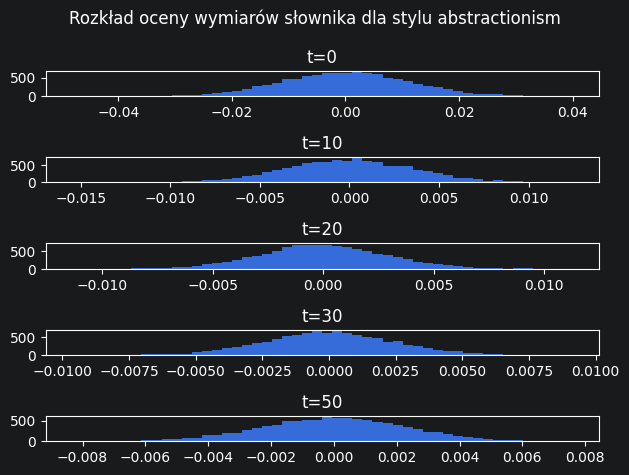

Top 10 wymiarów słownika (zagregowane po krokach czasowych tensor([9277,  663, 5708, 9391, 5406, 7666, 7677, 4490, 3709,  835])


{9277: -0.3150964677333832,
 663: -0.5785388350486755,
 5708: -0.0997006744146347,
 9391: -0.11663304269313812,
 5406: -0.4028443992137909,
 7666: -0.44385766983032227,
 7677: -0.4122329354286194,
 4490: -0.35500454902648926,
 3709: -0.48453497886657715,
 835: -0.2735205292701721}

In [9]:
analyze_style("abstractionism", representations_dataset)


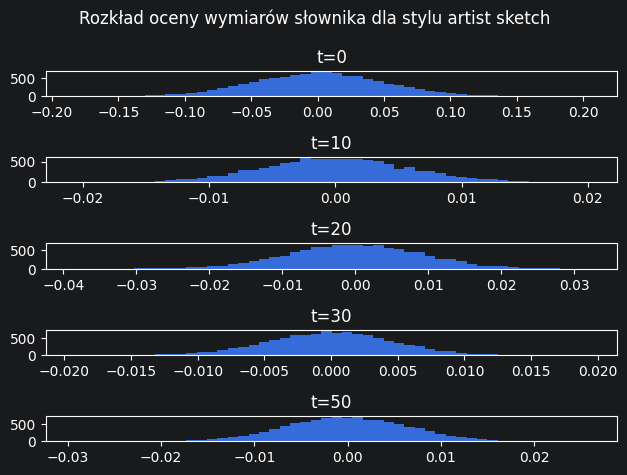

Top 10 wymiarów słownika (zagregowane po krokach czasowych tensor([5518, 4320, 4802, 6179, 3718, 6905, 5087, 7055,  426, 2821])


{5518: -0.7107505202293396,
 4320: -0.6993359327316284,
 4802: -0.8586661219596863,
 6179: -0.7275573015213013,
 3718: -0.9358670115470886,
 6905: -0.48176902532577515,
 5087: -0.585903525352478,
 7055: -0.9008421897888184,
 426: -0.48766735196113586,
 2821: -0.6156529188156128}

In [10]:
analyze_style("artist sketch", representations_dataset)

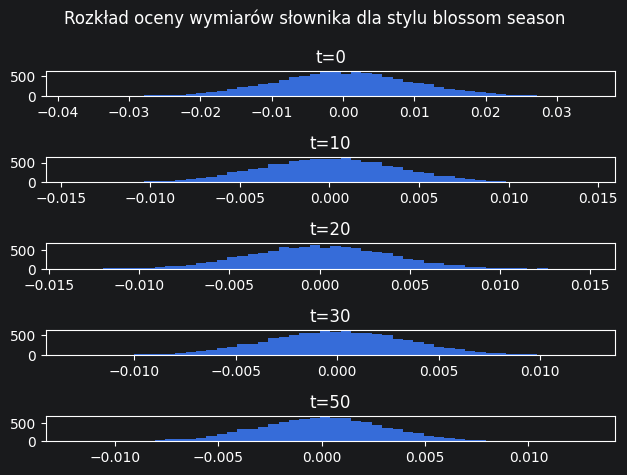

Top 10 wymiarów słownika (zagregowane po krokach czasowych tensor([8452, 6619, 5542, 1097, 4840,  707,  890, 8600, 8010,  399])


{8452: -0.2592393159866333,
 6619: -0.27215901017189026,
 5542: 0.0611380934715271,
 1097: -0.23795735836029053,
 4840: -0.2493765652179718,
 707: -0.19611291587352753,
 890: -0.14522433280944824,
 8600: 0.09378417581319809,
 8010: -0.30719760060310364,
 399: -0.5568557977676392}

In [11]:
analyze_style("blossom season", representations_dataset)

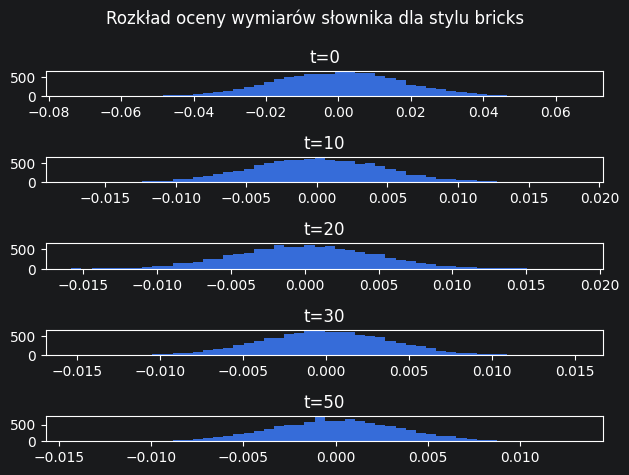

Top 10 wymiarów słownika (zagregowane po krokach czasowych tensor([4400, 4382, 4912, 8600, 6998, 1492, 4667, 6368, 6984, 9673])


{4400: 0.15077823400497437,
 4382: -0.09356039017438889,
 4912: 0.10672266036272049,
 8600: -0.01585463248193264,
 6998: -0.2661287784576416,
 1492: -0.06717679649591446,
 4667: 0.07528870552778244,
 6368: 0.2788570523262024,
 6984: -0.01777736097574234,
 9673: -0.06676457822322845}

In [12]:
analyze_style("bricks", representations_dataset)

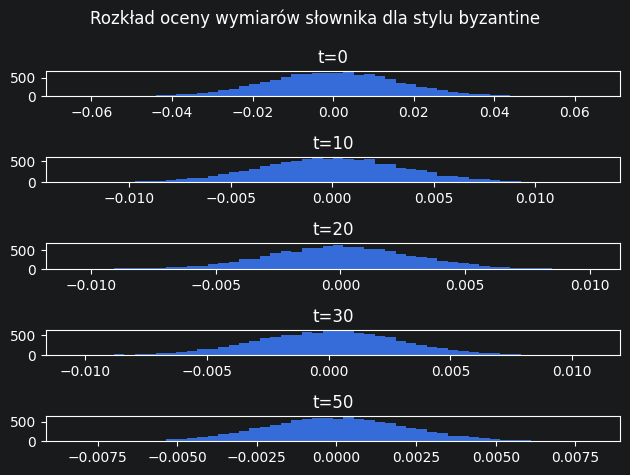

Top 10 wymiarów słownika (zagregowane po krokach czasowych tensor([6984,  778,  346, 5858, 3223, 5806, 9212, 5660, 5902,  582])


{6984: 0.1577005535364151,
 778: 0.05815662443637848,
 346: 0.2578330636024475,
 5858: 0.010164301842451096,
 3223: -0.0017870028968900442,
 5806: -0.37349051237106323,
 9212: -0.19979119300842285,
 5660: 0.23284435272216797,
 5902: -0.03576475381851196,
 582: 0.4320983588695526}

In [13]:
analyze_style("byzantine", representations_dataset)

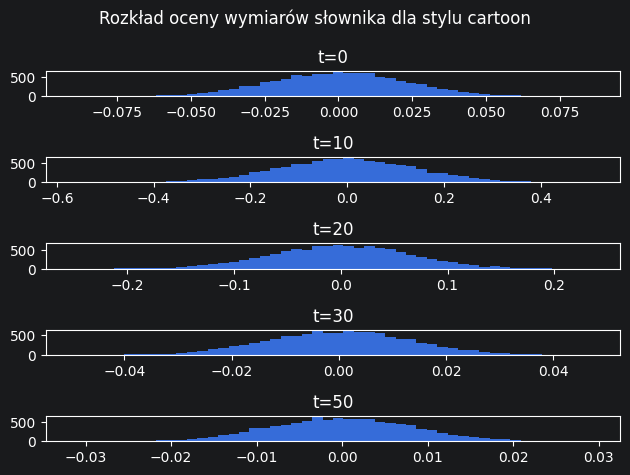

Top 10 wymiarów słownika (zagregowane po krokach czasowych tensor([6559, 2532, 9874, 7044, 5518, 6203, 2778, 7055, 7214, 5126])


{6559: -1.02586829662323,
 2532: -0.8932428359985352,
 9874: -0.9567275643348694,
 7044: -0.841062605381012,
 5518: -0.9184314012527466,
 6203: -0.8949572443962097,
 2778: -0.8383631706237793,
 7055: -0.8107898235321045,
 7214: -0.8432652354240417,
 5126: -0.8369369506835938}

In [14]:
analyze_style("cartoon", representations_dataset)